[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/BMED365-2026/blob/main/Lab3-GenAI-LLM/notebooks/05-xai-explainable-ai.ipynb)

# Explainable AI (XAI) in Medicine

**ELMED219 / BMED365 - Lab 3**

Last updated: 2026-01-18, A. Lundervold

---

## 🎯 Learning Objectives

By the end of this notebook, you will be able to:

| Objective | Description |
|-----------|-------------|
| **Understand XAI importance** | Explain why explainability is critical for trust, accountability, and regulation in medical AI |
| **Distinguish XAI types** | Differentiate between global vs. local, and ante-hoc vs. post-hoc explainability |
| **Apply SHAP analysis** | Understand how Shapley values from game theory explain feature contributions |
| **Apply LIME analysis** | Explain how local surrogate models create interpretable explanations |
| **Interpret attention mechanisms** | Analyze attention weights while understanding their limitations |
| **Meet clinical requirements** | Discuss what clinicians need from AI explanations and EU AI Act requirements |

## Overview

| Concept | Analogy | Role in Medical AI |
|---------|---------|-------------------|
| **XAI** | Doctor explaining diagnosis to patient | Makes AI reasoning transparent and trustworthy |
| **SHAP** | Splitting a restaurant bill fairly | Assigns fair "credit" to each feature |
| **LIME** | Studying a small neighborhood | Explains one prediction using a simpler local model |
| **Attention** | Highlighting important words in text | Shows what the model "looks at" (but not always "why") |

### Why This Matters for Healthcare

- 🏥 **Trust**: Doctors won't follow AI recommendations they don't understand
- ⚖️ **Accountability**: When errors occur, we need to know what went wrong
- 📋 **Regulation**: EU AI Act classifies medical AI as "high-risk" requiring explainability
- 🔬 **Discovery**: Good explanations can reveal new medical knowledge
- 🐛 **Debugging**: Identify bias, spurious correlations, or errors in the model

## Contents

1. [Why Explainable AI?](#1-why-explainable-ai)
2. [Types of Explainability](#2-types-of-explainability)
3. [SHAP - SHapley Additive exPlanations](#3-shap)
4. [LIME - Local Interpretable Model-agnostic Explanations](#4-lime)
5. [Attention-based Explanations](#5-attention-based-explanations)
6. [Clinical Requirements and Challenges](#6-clinical-requirements-and-challenges)
7. [Glossary of Key Terms](#7-glossary-of-key-terms)
8. [Key Takeaways](#8-key-takeaways)
9. [Further Reading](#9-further-reading)

---

## 1. Why Explainable AI?

In healthcare, it's not enough that AI gives the right answer - we must also understand **why**.

### Reasons Why XAI is Critical in Medicine

| Reason | Explanation |
|-------|------------|
| **Trust** | Doctors must trust AI recommendations before acting |
| **Accountability** | When errors occur, we must understand what went wrong |
| **Regulation** | EU AI Act requires explainability for high-risk AI |
| **Learning** | Explanations can reveal new medical knowledge |
| **Debugging** | Identify bias or errors in the model |

### The Black Box

Complex models like deep neural networks and LLMs are often called "black boxes" because:

```
Input (Patient Data)  →  [???]  →  Output (Diagnosis/Risk)
         ↓                              ↓
    We understand              We see the answer
    what goes in              but not WHY
```

XAI methods try to open this box.

In [1]:
# =============================================================================
# ENVIRONMENT SETUP - Ensuring Reproducibility
# =============================================================================
# This cell sets up the environment for all XAI demonstrations.
# IMPORTANT: We set random seeds to ensure reproducible results across runs.

import sys
import numpy as np
import matplotlib.pyplot as plt
import random

# -----------------------------------------------------------------------------
# REPRODUCIBILITY: Set random seeds for all libraries
# -----------------------------------------------------------------------------
# Why? Medical AI research requires reproducible results. Setting seeds ensures:
# - Same random values each time the notebook runs
# - Consistent visualizations for teaching and publication
# - Easier debugging and comparison of results

RANDOM_SEED = 42  # The Answer to Life, the Universe, and Everything
np.random.seed(RANDOM_SEED)      # NumPy random number generator
random.seed(RANDOM_SEED)          # Python's built-in random module

# -----------------------------------------------------------------------------
# MATPLOTLIB CONFIGURATION
# -----------------------------------------------------------------------------
plt.rcParams['figure.dpi'] = 100  # Higher DPI for clearer figures
plt.rcParams['figure.figsize'] = [10, 6]  # Default figure size

# -----------------------------------------------------------------------------
# ENVIRONMENT DETECTION (Colab vs Local)
# -----------------------------------------------------------------------------
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    print("Running in Google Colab")
    # Note: In Colab, you may need to install packages with !pip install
else:
    print("Running in local environment")

print("Ready for XAI demonstrations!")
print(f"Random seed set to {RANDOM_SEED} for reproducibility")

Running in local environment
Ready for XAI demonstrations!
Random seed set to 42 for reproducibility


---

## 2. Types of Explainability

### Global vs. Local Explainability

| Type | Question | Example |
|------|----------|----------|
| **Global** | How does the model work in general? | "Blood pressure is the most important factor for heart disease" |
| **Local** | Why this answer for this patient? | "This patient got high risk due to smoking + high cholesterol" |

### Ante-hoc vs. Post-hoc

| Type | When | Example |
|------|-----|----------|
| **Ante-hoc** | Built into the model | Decision trees, linear regression |
| **Post-hoc** | Analyzes finished model | SHAP, LIME, GradCAM |

In [2]:
# =============================================================================
# EXAMPLE: ANTE-HOC EXPLAINABILITY - Interpretable by Design
# =============================================================================
# This demonstrates an "ante-hoc" (beforehand) interpretable model.
# The model is transparent: we can explain EVERY decision just by reading the code.

# Interpretable model: Point-based risk scoring system
# Similar to real clinical scores like CHADS-VASc (stroke risk) or CURB-65 (pneumonia)
def interpretable_risk_score(age, blood_pressure, cholesterol, smoker):
    """
    A simple, fully interpretable cardiovascular risk scoring model.
    
    This is an example of ANTE-HOC explainability: the model itself is 
    transparent. We don't need post-hoc methods like SHAP or LIME because
    we can read the logic directly.
    
    Parameters:
    -----------
    age : int
        Patient's age in years
    blood_pressure : int  
        Systolic blood pressure in mmHg
    cholesterol : float
        Total cholesterol in mmol/L
    smoker : bool
        Whether the patient currently smokes
        
    Returns:
    --------
    int : Risk score (0-9), higher = higher risk
    """
    score = 0
    
    # Age risk: Known major risk factor for cardiovascular disease
    # Clinical threshold: Risk increases significantly after 40, more after 60
    if age > 60:
        score += 2  # High age contribution
    elif age > 40:
        score += 1  # Moderate age contribution
    
    # Blood pressure: Hypertension is a leading CVD risk factor
    # 140 mmHg is the clinical threshold for Stage 2 hypertension
    if blood_pressure > 140:
        score += 2  # Hypertensive
    elif blood_pressure > 120:
        score += 1  # Elevated (pre-hypertension)
    
    # Cholesterol: Hyperlipidemia contributes to atherosclerosis
    # 6.5 mmol/L ≈ 250 mg/dL (high), 5.0 mmol/L ≈ 193 mg/dL (borderline)
    if cholesterol > 6.5:
        score += 2  # High cholesterol
    elif cholesterol > 5.0:
        score += 1  # Borderline high
    
    # Smoking: One of the strongest modifiable risk factors
    # Gets the highest single-factor score due to its strong impact
    if smoker:
        score += 3  # Significant risk increase
    
    return score

# Test on a patient
patient = {
    'age': 65,
    'blood_pressure': 145,
    'cholesterol': 6.8,
    'smoker': True
}

score = interpretable_risk_score(**patient)

print("INTERPRETABLE MODEL - Heart Disease Risk")
print("=" * 50)
print(f"Patient: {patient}")
print(f"Risk Score: {score}/9")
print()
print("Explanation (easy to understand):")
print(f"  - Age 65 years: +2 points (over 60)")
print(f"  - BP 145: +2 points (over 140)")
print(f"  - Cholesterol 6.8: +2 points (over 6.5)")
print(f"  - Smoker: +3 points")
print(f"  = Total {score} points")

INTERPRETABLE MODEL - Heart Disease Risk
Patient: {'age': 65, 'blood_pressure': 145, 'cholesterol': 6.8, 'smoker': True}
Risk Score: 9/9

Explanation (easy to understand):
  - Age 65 years: +2 points (over 60)
  - BP 145: +2 points (over 140)
  - Cholesterol 6.8: +2 points (over 6.5)
  - Smoker: +3 points
  = Total 9 points


### 💭 Self-Check: Types of Explainability

Test your understanding of explainability concepts:

1. **Match the term with its meaning:**
   - Global explainability → ___
   - Local explainability → ___
   
   Options:
   - A) Why did the model give THIS specific answer for THIS patient?
   - B) What patterns does the model use in general across all patients?

2. **The interpretable risk score above is an example of:**
   - a) Post-hoc explainability
   - b) Ante-hoc explainability
   - c) Local explainability
   - d) SHAP

3. **Why are simple models like decision trees and linear regression called "ante-hoc" interpretable?**

<details>
<summary>Click to reveal answers</summary>

1. **Global → B, Local → A** - Global explains the overall model behavior; local explains individual predictions.

2. **b) Ante-hoc explainability** - The model is interpretable by design. We can read the code and understand exactly why it gives any score.

3. **Built-in transparency** - "Ante-hoc" means "beforehand." These models are interpretable from the start because their structure (weights, rules, thresholds) is directly readable. No post-hoc analysis is needed.

</details>

---

## 3. SHAP - SHapley Additive exPlanations

SHAP is based on game theory (Shapley values) and explains predictions by calculating each feature's contribution.

### How SHAP Works

1. For a given prediction, SHAP calculates how much **each feature** contributes to moving the prediction from the average
2. Positive SHAP values increase the prediction, negative values decrease it
3. Sum of all SHAP values = prediction - average prediction

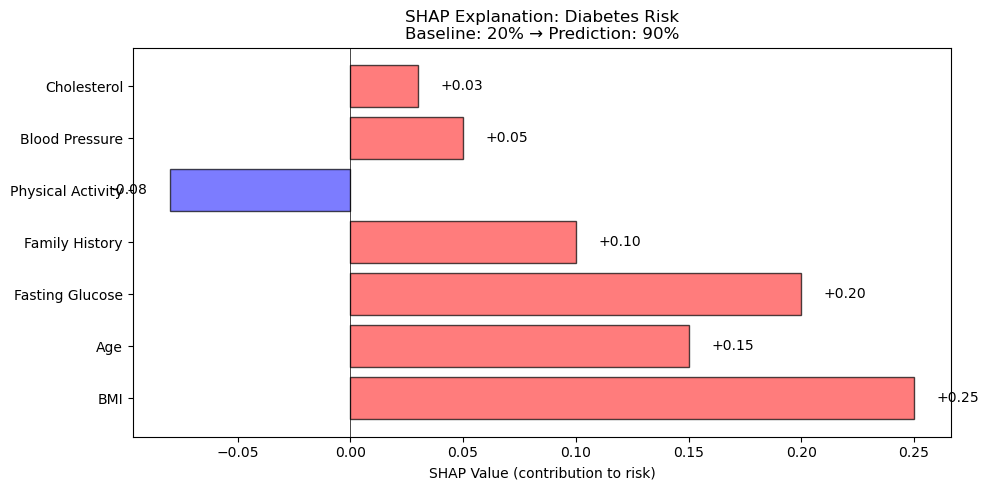


Interpretation for clinician:
--------------------------------------------------
This patient has 90% risk of diabetes (average: 20%)

Main causes of increased risk:
  - BMI: +0.25
  - Fasting Glucose: +0.20
  - Age: +0.15


In [3]:
# =============================================================================
# SHAP EXPLANATION DEMONSTRATION
# =============================================================================
# SHAP (SHapley Additive exPlanations) comes from cooperative game theory.
# The key insight: treat each feature as a "player" contributing to the 
# prediction. Shapley values fairly distribute the "payout" (prediction) 
# among all players based on their marginal contributions.

def simulate_shap_explanation():
    """
    Simulates a SHAP explanation for a diabetes risk prediction model.
    
    In production, you would use the `shap` library:
        import shap
        explainer = shap.Explainer(model, X_train)
        shap_values = explainer(X_test)
    
    KEY CONCEPTS:
    - Baseline (E[f(x)]): Average prediction across all patients (population risk)
    - SHAP value: How much each feature pushes the prediction away from baseline
    - Sum property: baseline + sum(SHAP values) = final prediction
    
    Returns:
    --------
    tuple: (feature names, SHAP values, baseline prediction, final prediction)
    """
    # Clinical features for diabetes risk assessment
    features = ['BMI', 'Age', 'Fasting Glucose', 'Family History', 
                'Physical Activity', 'Blood Pressure', 'Cholesterol']
    
    # SHAP values (simulated for this patient)
    # Positive values INCREASE predicted risk, negative values DECREASE it
    shap_values = [
        0.25,   # BMI: High value → strong risk increase
        0.15,   # Age: Older → moderate risk increase  
        0.20,   # Fasting Glucose: Elevated → strong risk increase
        0.10,   # Family History: Positive → moderate risk increase
        -0.08,  # Physical Activity: Active → risk DECREASE (protective!)
        0.05,   # Blood Pressure: Slightly elevated → small increase
        0.03    # Cholesterol: Normal range → minimal contribution
    ]
    
    # The SHAP additivity property:
    baseline = 0.20  # Average diabetes risk in this population (E[f(x)])
    prediction = baseline + sum(shap_values)  # 0.20 + 0.70 = 0.90 (90% risk!)
    
    return features, shap_values, baseline, prediction

# Generate the explanation
features, shap_values, baseline, prediction = simulate_shap_explanation()

# -----------------------------------------------------------------------------
# VISUALIZATION: SHAP Waterfall-style Bar Plot
# -----------------------------------------------------------------------------
# Red bars push prediction UP (increase risk)
# Blue bars push prediction DOWN (decrease risk)

fig, ax = plt.subplots(figsize=(10, 5))

# Color-code by direction of contribution
colors = ['#ff4444' if v > 0 else '#4444ff' for v in shap_values]
y_pos = range(len(features))

ax.barh(y_pos, shap_values, color=colors, alpha=0.7, edgecolor='black')
ax.set_yticks(y_pos)
ax.set_yticklabels(features)
ax.set_xlabel('SHAP Value (contribution to risk)')
ax.set_title(f'SHAP Explanation: Diabetes Risk\nBaseline: {baseline:.0%} → Prediction: {prediction:.0%}')
ax.axvline(x=0, color='black', linewidth=0.5)

# Add values on bars
for i, (feature, value) in enumerate(zip(features, shap_values)):
    ax.text(value + 0.01 if value > 0 else value - 0.01, i, 
            f'{value:+.2f}', va='center', 
            ha='left' if value > 0 else 'right')

plt.tight_layout()
plt.show()

print("\nInterpretation for clinician:")
print("-" * 50)
print(f"This patient has {prediction:.0%} risk of diabetes (average: {baseline:.0%})")
print("\nMain causes of increased risk:")
for f, v in sorted(zip(features, shap_values), key=lambda x: x[1], reverse=True)[:3]:
    print(f"  - {f}: {v:+.2f}")

### Advantages and Disadvantages of SHAP

| Advantages | Disadvantages |
|----------|----------|
| Theoretical foundation (Shapley) | Can be computationally demanding |
| Consistent and fair | Explanations can be difficult to interpret |
| Works for all model types | Requires access to training data |

### 💭 Self-Check: SHAP

Test your understanding of SHAP values:

1. **The sum of all SHAP values for a prediction equals:**
   - a) 1.0 (100%)
   - b) The prediction minus the baseline (average prediction)
   - c) The number of features
   - d) Zero

2. **A negative SHAP value for "Physical Activity" in a diabetes risk model means:**
   - a) The feature wasn't measured
   - b) The feature REDUCES the predicted risk for this patient
   - c) The feature is broken
   - d) The model is wrong

3. **What game theory concept is SHAP based on?**

4. **Why might SHAP be preferred over simpler methods for explaining medical AI?**

<details>
<summary>Click to reveal answers</summary>

1. **b) The prediction minus the baseline (average prediction)** - This is the additivity property of SHAP: base_value + sum(SHAP values) = prediction.

2. **b) The feature REDUCES the predicted risk for this patient** - Negative SHAP values indicate the feature pushed the prediction toward lower risk (protective effect).

3. **Shapley values** - From cooperative game theory, they fairly distribute a "payout" among players based on their marginal contributions to all possible coalitions.

4. **Theoretical guarantees** - SHAP provides mathematically fair attribution with properties like local accuracy, missingness, and consistency. Important for clinical trust and regulatory compliance.

</details>

---

## 4. LIME - Local Interpretable Model-agnostic Explanations

LIME explains individual predictions by building a simple, interpretable model locally around the prediction.

### How LIME Works

1. Generate perturbed versions of input (with small changes)
2. Get predictions for all perturbed versions
3. Train a simple model (e.g., linear) on these
4. Use the simple model to explain

LIME Explanation for Text Classification
Input: 'The patient has chest pain and shortness of breath during exertion'
Classification: Heart Disease (probability: 85%)

Interpretation: The model focused on clinical symptom words

Words contributing to classification:
  chest           ███████ (+0.35)
  pain            ███████ (+0.35)
  shortness       █████ (+0.25)
  breath          █████ (+0.25)
  exertion        ███ (+0.15)


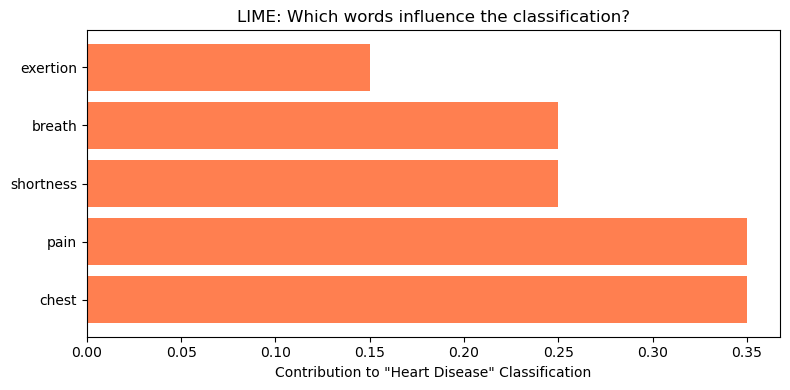

In [4]:
# =============================================================================
# LIME EXPLANATION DEMONSTRATION
# =============================================================================
# LIME (Local Interpretable Model-agnostic Explanations) works differently:
# 1. Take ONE prediction you want to explain
# 2. Create many "perturbed" versions (slightly modified inputs)
# 3. Get the black-box model's predictions for all perturbations
# 4. Fit a SIMPLE, interpretable model (like linear regression) locally
# 5. Use the simple model's weights to explain the original prediction

# KEY INSIGHT: LIME doesn't try to explain the whole model (global).
# It only explains the LOCAL neighborhood around one specific prediction.

def simulate_lime_text_explanation():
    """
    Simulates a LIME explanation for a medical text classification task.
    
    In production, you would use the `lime` library:
        from lime.lime_text import LimeTextExplainer
        explainer = LimeTextExplainer(class_names=['Healthy', 'Heart Disease'])
        exp = explainer.explain_instance(text, classifier.predict_proba)
        exp.show_in_notebook()
    
    This simulates a classifier that predicts "Heart Disease" based on 
    clinical notes. LIME shows which words most influenced the decision.
    
    Returns:
    --------
    tuple: (input text, dictionary of word contributions)
    """
    # A clinical note that might trigger a heart disease classification
    text = "The patient has chest pain and shortness of breath during exertion"
    
    # LIME's word contributions to the "Heart Disease" classification
    # These represent the weights from the local linear model
    # Higher positive value = word pushes toward Heart Disease classification
    word_contributions = {
        'chest': 0.35,      # Clinical symptom - very relevant
        'pain': 0.35,       # Clinical symptom - very relevant  
        'shortness': 0.25,  # Key symptom phrase (with "breath")
        'breath': 0.25,     # Key symptom phrase (with "shortness")
        'exertion': 0.15,   # Exercise intolerance - relevant
        'The': 0.0,         # Stop word - no diagnostic value
        'patient': 0.0,     # Generic term - no diagnostic value
        'has': 0.0,         # Stop word - no diagnostic value
        'and': 0.0,         # Stop word - no diagnostic value
        'of': 0.0,          # Stop word - no diagnostic value
        'during': 0.0       # Temporal word - minimal contribution
    }
    
    return text, word_contributions

# Generate the LIME explanation
text, word_contributions = simulate_lime_text_explanation()

# -----------------------------------------------------------------------------
# Print the explanation in a clinical format
# -----------------------------------------------------------------------------
print("LIME Explanation for Text Classification")
print("=" * 50)
print(f"Input: '{text}'")
print(f"Classification: Heart Disease (probability: 85%)")
print(f"\nInterpretation: The model focused on clinical symptom words")
print()
print("Words contributing to classification:")
for word, contribution in sorted(word_contributions.items(), key=lambda x: x[1], reverse=True):
    if contribution > 0:
        bar = '█' * int(contribution * 20)
        print(f"  {word:15s} {bar} ({contribution:+.2f})")

# Visualize
important_words = [(k, v) for k, v in word_contributions.items() if v > 0]
words, values = zip(*important_words)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(words, values, color='coral')
ax.set_xlabel('Contribution to "Heart Disease" Classification')
ax.set_title('LIME: Which words influence the classification?')
plt.tight_layout()
plt.show()

### 💭 Self-Check: LIME

Test your understanding of LIME:

1. **What does "Local" mean in LIME?**
   - a) The model runs on your local computer
   - b) It explains only one prediction at a time in its neighborhood
   - c) It only works for location-based data
   - d) The explanation is stored locally

2. **How does LIME create explanations?**
   - a) By reading the model's source code
   - b) By training a simple model on perturbed versions of the input
   - c) By using the model's attention weights
   - d) By calculating Shapley values

3. **In the text classification example, why did function words like "the" and "has" have zero contribution?**

<details>
<summary>Click to reveal answers</summary>

1. **b) It explains only one prediction at a time in its neighborhood** - LIME builds a local approximation around a single instance.

2. **b) By training a simple model on perturbed versions of the input** - LIME generates variations of the input, gets predictions, and fits an interpretable model.

3. **Function words lack diagnostic value** - Words like "the", "has", "and" appear in all medical texts regardless of diagnosis, so they don't help distinguish between classes.

</details>

---

## 5. Attention-based Explanations

For transformer models like LLMs, we can visualize **attention weights** to see what the model "focuses" on.

### Important Caveat

Attention is *not* the same as explanation! Research shows that:
- High attention does not necessarily mean causal influence
- The same prediction can have different attention patterns
- Attention can be misleading

However, it can still provide useful insights as a starting point for further analysis.

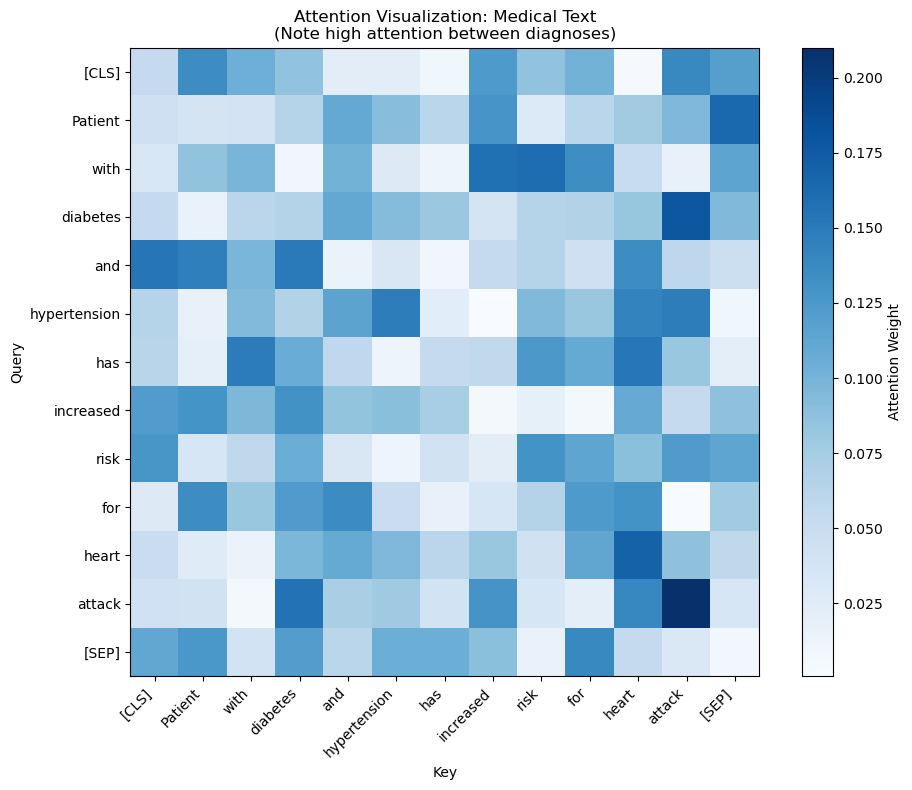

Observation:
The model shows high attention between 'diabetes', 'hypertension' and 'heart attack',
which indicates that it has learned the relationship between these diagnoses.


In [5]:
# =============================================================================
# ATTENTION-BASED EXPLANATIONS
# =============================================================================
# Transformers (like BERT, GPT, and medical LLMs) use attention mechanisms.
# Attention weights show what tokens the model "focuses on" when making predictions.

# IMPORTANT CAVEAT (from research like "Attention is not Explanation" - Jain & Wallace):
# - Attention shows correlation, NOT causation
# - Different attention patterns can produce the same prediction
# - Attention can be manipulated without changing outputs
# - Use attention as a hypothesis generator, not as definitive explanation

import matplotlib.pyplot as plt
import numpy as np

def visualize_attention_medical():
    """
    Simulates attention weights for a medical sentence in a BERT-like model.
    
    In production, you would extract attention from a real model:
        from transformers import AutoModel, AutoTokenizer
        model = AutoModel.from_pretrained("dmis-lab/biobert-base-cased-v1.2")
        outputs = model(input_ids, attention_mask, output_attentions=True)
        attention = outputs.attentions  # Tuple of attention per layer
    
    This simulation shows how medical terms (diseases) might attend to each other,
    suggesting the model has learned clinical relationships.
    
    Returns:
    --------
    tuple: (list of tokens, 2D attention matrix)
    """
    # BERT-style tokenization with special tokens
    # [CLS] = classification token, [SEP] = separator token
    tokens = ['[CLS]', 'Patient', 'with', 'diabetes', 'and', 'hypertension', 
              'has', 'increased', 'risk', 'for', 'heart', 'attack', '[SEP]']
    
    # Create base attention matrix with random values
    # Using consistent seed for reproducibility
    np.random.seed(42)
    attention = np.random.rand(len(tokens), len(tokens))
    
    # Simulate clinical pattern: disease terms attend strongly to each other
    # This mimics what we'd expect from a model that learned medical relationships
    disease_idx = [3, 5, 10, 11]  # indices: diabetes, hypertension, heart, attack
    for i in disease_idx:
        for j in disease_idx:
            attention[i, j] += 0.5  # Boost attention between medical concepts
    
    # Normalize rows (attention is a probability distribution per query token)
    attention = attention / attention.sum(axis=1, keepdims=True)
    
    return tokens, attention

# Generate the attention pattern
tokens, attention = visualize_attention_medical()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(attention, cmap='Blues')

ax.set_xticks(range(len(tokens)))
ax.set_yticks(range(len(tokens)))
ax.set_xticklabels(tokens, rotation=45, ha='right')
ax.set_yticklabels(tokens)

ax.set_xlabel('Key')
ax.set_ylabel('Query')
ax.set_title('Attention Visualization: Medical Text\n(Note high attention between diagnoses)')

plt.colorbar(im, label='Attention Weight')
plt.tight_layout()
plt.show()

print("Observation:")
print("The model shows high attention between 'diabetes', 'hypertension' and 'heart attack',")
print("which indicates that it has learned the relationship between these diagnoses.")

### 💭 Self-Check: Attention-based Explanations

Test your understanding of attention mechanisms as explanations:

1. **True or False**: High attention weight on a word means that word *caused* the model's prediction.

2. **Why is attention sometimes called "not explanation" in research?**
   - a) It's too computationally expensive
   - b) Different attention patterns can produce the same prediction
   - c) It only works for image models
   - d) It requires too much training data

3. **When analyzing attention weights in a clinical NLP model, what should you do?**
   - a) Accept them as definitive explanations of model reasoning
   - b) Use them as hypotheses for further investigation
   - c) Ignore them entirely since they're useless
   - d) Only look at the [CLS] token attention

<details>
<summary>Click to reveal answers</summary>

1. **False** - Attention shows correlation, not causation. The model might attend to a word but the prediction could still be the same without it.

2. **b) Different attention patterns can produce the same prediction** - Research by Jain & Wallace showed that attention weights can be manipulated without changing outputs.

3. **b) Use them as hypotheses for further investigation** - Attention can provide useful starting points for analysis, but should be validated with other methods.

</details>

---

## 6. Clinical Requirements and Challenges

### What Do Clinicians Need?

Research shows that doctors want explanations that are:

1. **Short and precise** - not long technical reports
2. **Clinically relevant** - related to known risk factors
3. **Actionable** - provide basis for making decisions
4. **Honest about uncertainty** - don't oversell the model's confidence

### EU AI Act and Explainability

Under the EU's AI regulation, medical AI is often classified as **high-risk**, which requires:

- Documentation of how the model works
- Possibility for human override
- Logging of decisions
- Explanations tailored to users

In [6]:
# =============================================================================
# CLINICAL EXPLANATION DESIGN
# =============================================================================
# The ULTIMATE goal of XAI in medicine: Explanations that help clinicians!
# Research shows clinicians want explanations that are:
# 1. SHORT - No time to read pages of technical output
# 2. RELEVANT - Connected to known clinical risk factors
# 3. ACTIONABLE - Can inform clinical decisions
# 4. HONEST - Clear about uncertainty and limitations

# This function demonstrates a production-ready explanation format
# that translates technical XAI outputs into clinical language.

def generate_clinical_explanation(patient, risk, factors):
    """
    Generates a clinician-friendly explanation for an AI risk assessment.
    
    Design principles (from human-computer interaction research):
    - Box format draws attention
    - Risk factors are ranked by importance
    - Arrows (↑↓) provide quick visual direction
    - Uncertainty is always disclosed
    - Disclaimer protects against over-reliance
    
    Parameters:
    -----------
    patient : dict
        Patient identifier information
    risk : dict
        Contains 'category', 'score', and 'confidence'
    factors : list of tuples
        Each tuple: (factor_name, contribution_string, direction)
        direction is 'increases' or 'decreases'
    
    Returns:
    --------
    str : Formatted clinical explanation ready for display
    """
    # Build the explanation using a structured clinical format
    explanation = f"""
╔══════════════════════════════════════════════════════════════╗
║  AI-SUPPORTED RISK ASSESSMENT                                ║
╚══════════════════════════════════════════════════════════════╝

PATIENT: {patient['id']}
ASSESSMENT: {risk['category']} ({risk['score']:.0%})

MAIN FACTORS (from AI analysis):
"""
    # List factors with visual indicators for direction
    for i, (factor, contribution, direction) in enumerate(factors, 1):
        arrow = "↑" if direction == 'increases' else "↓"
        explanation += f"  {i}. {factor} {arrow} ({contribution})\n"
    
    # Always include uncertainty - critical for clinical trust
    explanation += f"""
UNCERTAINTY: The model is {risk['confidence']}% confident in this assessment.

⚠️  IMPORTANT: This is decision support, not a diagnosis.
    Clinical judgment is always required.
"""
    return explanation

# Test
patient = {'id': 'P-2024-001'}
risk = {'category': 'High Risk', 'score': 0.78, 'confidence': 85}
factors = [
    ('Age over 65 years', '+15%', 'increases'),
    ('Type 2 Diabetes', '+12%', 'increases'),
    ('Active smoker', '+18%', 'increases'),
    ('Regular exercise', '-8%', 'decreases')
]

print(generate_clinical_explanation(patient, risk, factors))


╔══════════════════════════════════════════════════════════════╗
║  AI-SUPPORTED RISK ASSESSMENT                                ║
╚══════════════════════════════════════════════════════════════╝

PATIENT: P-2024-001
ASSESSMENT: High Risk (78%)

MAIN FACTORS (from AI analysis):
  1. Age over 65 years ↑ (+15%)
  2. Type 2 Diabetes ↑ (+12%)
  3. Active smoker ↑ (+18%)
  4. Regular exercise ↓ (-8%)

UNCERTAINTY: The model is 85% confident in this assessment.

⚠️  IMPORTANT: This is decision support, not a diagnosis.
    Clinical judgment is always required.



---

## 7. Glossary of Key Terms

### Explainability Concepts

| Term | Definition |
|------|------------|
| **Explainable AI (XAI)** | Field focused on making AI decisions understandable to humans |
| **Interpretability** | Degree to which a human can understand the cause of a decision |
| **Transparency** | Ability to describe model mechanisms in understandable terms |
| **Black box** | Model whose internal workings are not directly understandable |
| **Global explainability** | Understanding model behavior across all predictions |
| **Local explainability** | Understanding why a specific prediction was made |
| **Ante-hoc** | Interpretability built into the model design (before training) |
| **Post-hoc** | Explanation methods applied after model is trained |

### XAI Methods

| Term | Definition |
|------|------------|
| **SHAP** | SHapley Additive exPlanations - game theory-based feature attribution |
| **Shapley values** | Fair way to distribute a payout among players (features) |
| **LIME** | Local Interpretable Model-agnostic Explanations - local surrogate models |
| **Perturbation** | Small modifications to input to test model sensitivity |
| **Surrogate model** | Simple, interpretable model that approximates a complex model |
| **Attention weights** | Values showing how much a model "focuses" on different inputs |
| **GradCAM** | Gradient-weighted Class Activation Mapping for visual explanations |
| **Feature attribution** | Assigning importance scores to input features |

### Clinical and Regulatory Context

| Term | Definition |
|------|------------|
| **EU AI Act** | European regulation classifying AI systems by risk level |
| **High-risk AI** | AI applications (including medical) requiring special oversight |
| **Decision support** | AI that assists but doesn't replace human decision-making |
| **Algorithmic transparency** | Requirement to explain AI logic to affected individuals |
| **Right to explanation** | Legal requirement for humans to receive explanations of AI decisions |

---

## 8. Key Takeaways

```
┌──────────────────────────────────────────────────────────────────────────────┐
│                    EXPLAINABLE AI (XAI) IN MEDICINE                          │
├──────────────────────────────────────────────────────────────────────────────┤
│                                                                              │
│  WHY XAI MATTERS:                                                            │
│  ────────────────                                                            │
│  • Trust: Clinicians need to understand AI before acting on it               │
│  • Accountability: When errors occur, we must trace what went wrong          │
│  • Regulation: EU AI Act requires explainability for high-risk AI            │
│  • Discovery: Good explanations can reveal new medical knowledge             │
│                                                                              │
│  EXPLAINABILITY TYPES:                                                       │
│  ─────────────────────                                                       │
│  • Global vs Local: Overall model behavior vs. single prediction             │
│  • Ante-hoc vs Post-hoc: Built into model vs. applied after training         │
│                                                                              │
│  XAI METHODS COMPARISON:                                                     │
│  ───────────────────────                                                     │
│  ┌─────────┬─────────────────────────┬─────────────────────────────────────┐ │
│  │ Method  │ Strength                │ Limitation                          │ │
│  ├─────────┼─────────────────────────┼─────────────────────────────────────┤ │
│  │ SHAP    │ Theoretically grounded  │ Computationally expensive           │ │
│  │ LIME    │ Model-agnostic, fast    │ Explanations can vary               │ │
│  │ Attent. │ Built into transformers │ Not causal, can be misleading       │ │
│  └─────────┴─────────────────────────┴─────────────────────────────────────┘ │
│                                                                              │
│  CLINICAL REQUIREMENTS:                                                      │
│  ──────────────────────                                                      │
│  Explanations must be: SHORT • RELEVANT • ACTIONABLE • HONEST                │
│                                                                              │
└──────────────────────────────────────────────────────────────────────────────┘
```

### What You've Learned

**XAI Fundamentals:**
- ✅ Why explainability is non-negotiable in medical AI
- ✅ The difference between global and local explanations
- ✅ Ante-hoc (interpretable by design) vs. post-hoc (explain after training)

**XAI Methods:**
- ✅ SHAP: Game theory-based fair attribution of feature importance
- ✅ LIME: Local surrogate models for any black-box model
- ✅ Attention: Useful but NOT the same as causal explanation

**Clinical Application:**
- ✅ What clinicians actually need from AI explanations
- ✅ EU AI Act requirements for high-risk medical AI
- ✅ Designing explanations that support (not replace) clinical judgment

### Reflection Questions

Think about these questions to deepen your understanding:

1. **SHAP vs. LIME**: When would you prefer one over the other? Consider computation time, theoretical guarantees, and the type of model.

2. **Audience matters**: How would you explain an AI risk assessment to:
   - A patient with no technical background?
   - A specialist doctor?
   - A hospital administrator?
   - A regulatory body?

3. **Ethical implications**: What happens when AI is deployed without adequate explainability? Consider cases of bias, errors, and patient rights.

4. **Future directions**: As LLMs become more common in medicine, what new explainability challenges arise?

---

*These concepts are fundamental to responsible AI deployment in healthcare. The ability to explain AI decisions is not just technical—it's ethical, legal, and clinical.*

---

## 9. Further Reading

### Essential Papers

| Paper | Key Contribution |
|-------|-----------------|
| Lundberg & Lee (2017) - "A Unified Approach to Interpreting Model Predictions" | Introduced SHAP, unifying several explanation methods |
| Ribeiro et al. (2016) - "Why Should I Trust You?: Explaining the Predictions of Any Classifier" | Introduced LIME |
| Jain & Wallace (2019) - "Attention is not Explanation" | Critical analysis of attention as explanation |
| Rudin (2019) - "Stop Explaining Black Box Models and Use Interpretable Models Instead" | Argues for ante-hoc interpretability |

### Medical AI Explainability

- **Ghassemi et al. (2021)** - "The false hope of current approaches to explainable AI in health care" - *The Lancet Digital Health*
- **Amann et al. (2020)** - "Explainability for artificial intelligence in healthcare" - *BMC Medical Informatics*
- **Tonekaboni et al. (2019)** - "What Clinicians Want: Contextualizing Explainable Machine Learning for Clinical End Use" - *MLHC*

### Regulatory Context

- **EU AI Act** (2024) - [Full text](https://eur-lex.europa.eu/legal-content/EN/TXT/?uri=CELEX:32024R1689)
- **FDA Guidance on AI/ML** - [Clinical Decision Support Software](https://www.fda.gov/medical-devices/software-medical-device-samd/artificial-intelligence-and-machine-learning-aiml-enabled-medical-devices)

### Tools and Libraries

| Library | Use Case |
|---------|----------|
| `shap` | SHAP explanations for any model |
| `lime` | LIME explanations |
| `captum` | PyTorch model interpretability |
| `interpret` | Microsoft's unified interpretability toolkit |
| `transformers-interpret` | Attention visualization for Hugging Face models |

### Recommended Books

- Molnar, C. - *Interpretable Machine Learning* (Free online: [christophm.github.io/interpretable-ml-book](https://christophm.github.io/interpretable-ml-book/))
- O'Neil, C. - *Weapons of Math Destruction* (On algorithmic harm)

---

*Next notebook: [06 - AI Ethics in Medicine](06-ai-ethics-medicine.ipynb)*

---

## Reproducibility Notes

This notebook is designed for reproducible execution:

| Aspect | Implementation |
|--------|---------------|
| **Random seed** | `RANDOM_SEED = 42` set for NumPy and Python random |
| **Environment** | Works in both Google Colab and local environments |
| **Dependencies** | Standard scientific Python: NumPy, Matplotlib |
| **Visualizations** | Consistent DPI and figure sizes for reproducible plots |

### Running This Notebook

1. **Google Colab**: Click the "Open in Colab" badge at the top
2. **Local**: Use the `bmed365-2026` conda environment:
   ```bash
   conda activate bmed365-2026
   jupyter notebook 05-xai-explainable-ai.ipynb
   ```

### Version Information

To check your environment, run:
```python
import sys
import numpy as np
import matplotlib
print(f"Python: {sys.version}")
print(f"NumPy: {np.__version__}")
print(f"Matplotlib: {matplotlib.__version__}")
```

---

*Lab 3: Generative AI and Large Language Models | ELMED219 / BMED365*